# Create a joint plot to display the methodological advancements we did:
- effect of varying blocksize
- parameter tuning results

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import yaml

import numpy as np
import joblib
import os
import cmcrameri as cmc  # noqa: F401
from unseen_awg.plotting_utils import add_label_to_axes
import xarray as xr

In [2]:
mpl.rc_file("../../matplotlibrc")
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [3]:
corr_gt = xr.open_dataarray(
    os.path.join(
        paths["dir_results"],
        "autocorrelation",
        "5e06172f_f40e9460_1e69bda9_d13ad10f",
        "67209ec1_70d69d7b_gt.nc",
    )
)
corr_wg = xr.open_dataarray(
    os.path.join(
        paths["dir_results"],
        "autocorrelation",
        "5e06172f_f40e9460_1e69bda9_d13ad10f",
        "67209ec1_70d69d7b_wg.nc",
    )
).squeeze()

In [4]:
font_kwargs = dict(fontweight="bold", fontsize="large")

In [5]:
corr_wg

<xarray.DataArray 'var' (year: 21, seed: 500, blocksize: 3, lag: 20)> Size: 5MB
[630000 values with dtype=float64]
Coordinates:
  * year               (year) int64 168B 2003 2004 2005 2006 ... 2021 2022 2023
  * seed               (seed) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
  * blocksize          (blocksize) int64 24B 1 3 7
    latitude           float64 8B ...
    longitude          float64 8B ...
    probability_model  <U14 56B 'NoRestrictions'
    sigma              float64 8B 2.5
Dimensions without coordinates: lag

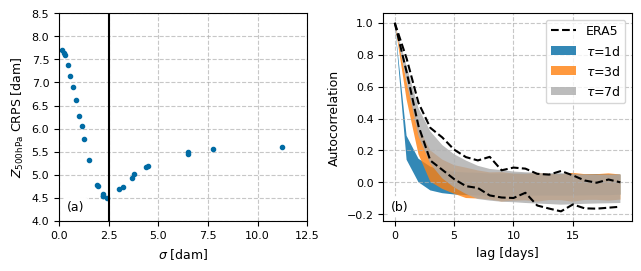

In [6]:
fig, axs = plt.subplots(1, 2)

fig.set_figheight(2.6)

lt = 3

configs = {
    "Reforecasts": os.path.join(
        paths["dir_wgs"], "wg_reforecasts_5e06172f_f40e9460_1e69bda9_tune"
    ),
}

param_configs = []
for i, (name, path) in enumerate(configs.items()):
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith("optuna_study.pkl"):
                base_file = file.strip("optuna_study.pkl")
                with open(os.path.join(path, base_file + "_params.yaml")) as file:
                    param_configs.append(yaml.safe_load(file))

    seeds = np.unique([cfg["seed"] for cfg in param_configs])
    n_analogs = np.unique([cfg["n_analogs"] for cfg in param_configs])
    lead_time_days = np.unique(
        [cfg["forecast_lead_time_days"] for cfg in param_configs]
    )

    n_trials = np.unique(
        [cfg["tune_weather_generator.N_optuna_trials"] for cfg in param_configs]
    )
    assert len(n_trials) == 1
    n_trials = n_trials[0]

    results = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days), n_trials),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={
            "seed": seeds,
            "n_analog": n_analogs,
            "lead_time": lead_time_days,
            "trial": np.arange(n_trials),
        },
    )

    sigma = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days), n_trials),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={
            "seed": seeds,
            "n_analog": n_analogs,
            "lead_time": lead_time_days,
            "trial": np.arange(n_trials),
        },
    )

    uses_seasonality = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days), n_trials),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={
            "seed": seeds,
            "n_analog": n_analogs,
            "lead_time": lead_time_days,
            "trial": np.arange(n_trials),
        },
    )

    crps_pers = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days)),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={"seed": seeds, "n_analog": n_analogs, "lead_time": lead_time_days},
    )

    crps_clim = xr.DataArray(
        np.full(
            (len(seeds), len(n_analogs), len(lead_time_days)),
            fill_value=np.nan,
            dtype=float,
        ),
        coords={"seed": seeds, "n_analog": n_analogs, "lead_time": lead_time_days},
    )

    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith("optuna_study.pkl"):
                base_file = file.strip("optuna_study.pkl")
                with open(os.path.join(path, base_file + "_params.yaml")) as f:
                    curr_conf = yaml.safe_load(f)

                seed = curr_conf["seed"]
                n_analog = curr_conf["n_analogs"]
                forecast_lead_time_days = curr_conf["forecast_lead_time_days"]
                pkl_file_path = os.path.join(root, file)
                # do something with the pkl file
                study = joblib.load(pkl_file_path)

                results.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = np.array([trial.value for trial in study.trials])
                sigma.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = np.array([trial.params["sigma"] for trial in study.trials])
                uses_seasonality.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = np.array(
                    [
                        True
                        if trial.params["probability_model_type"]
                        == "NormalProbabilityModelSeasonality"
                        else False
                        for trial in study.trials
                    ]
                )

                crps_pers.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = study.user_attrs["crps_pers"]
                crps_clim.loc[
                    {
                        "seed": seed,
                        "n_analog": n_analog,
                        "lead_time": forecast_lead_time_days,
                    }
                ] = study.user_attrs["crps_clim"]
    for j in range(len(sigma.n_analog)):
        for k in range(len(sigma.seed)):
            axs[0].scatter(
                sigma.isel(n_analog=j, seed=k).sel(lead_time=lt),
                results.isel(n_analog=j, seed=k).sel(lead_time=lt),
                color=f"C{j}",
                marker=".",
                zorder=2,
            )

axs[0].set_xlim(0, 8)
axs[0].set_ylim(4, 8.5)
axs[0].set_xticks(np.arange(0, 15.0, 2.5))


axs[0].set_ylabel(r"$Z_\mathrm{500hPa}$ CRPS [dam]")
axs[0].set_xlabel(r"$\sigma$ [dam]")
# axs[0].legend(loc="best")
axs[0].set_title("$3$day analog ensemble forecast\nperformance")

axs[0].axvline(2.5, color="k")

add_label_to_axes(ax=axs[0], ax_xpos=0.03, ax_ypos=0.1, label="(a)")


### second panel ###############################

q25_gt = corr_gt.quantile(0.25, dim="year")
q75_gt = corr_gt.quantile(0.75, dim="year")

q25_gt.plot(ax=axs[1], color="k", linestyle="dashed", label="ERA5")
q75_gt.plot(ax=axs[1], color="k", linestyle="dashed")
# corr_gt.median("year").plot(ax=ax, color="k")


q25_wg = corr_wg.quantile(0.25, dim=("year", "seed"))
q75_wg = corr_wg.quantile(0.75, dim=("year", "seed"))

for i, bs in enumerate(q25_wg.blocksize):
    # corr_wg.sel(blocksize=bs).median(dim=("year", "seed")).plot(color=f"C{i}")
    axs[1].fill_between(
        q25_wg.lag,
        q25_wg.sel(blocksize=bs),
        q75_wg.sel(blocksize=bs),
        alpha=0.8,
        label=rf"$\tau$={bs.data}d",
    )

axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("lag [days]")
axs[1].legend(loc="best")
axs[1].set_title(
    r"Leipzig summer $T_\mathrm{2m}$ autocorrelation" + "\n interquartile ranges"
)
axs[1].set_title("")
axs[0].set_title("")
add_label_to_axes(ax=axs[1], ax_xpos=0.03, ax_ypos=0.1, label="(b)")

# plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "tweaks.pdf"), dpi=300)